# Final Examination – AI & Data Science (Project-Based)

### Exam Overview
This examination is designed to assess your ability to apply Data Science, Machine Learning,
Deep Learning, and modern AI concepts in a real-world healthcare scenario.
You will work as a Data Scientist in a hospital network, where your task is to analyze patient
data, build predictive models, and propose AI-driven solutions to improve healthcare outcomes.

#### Industry Scenario

Hospitals often face a critical challenge:
Patients being readmitted within 30 days of discharge

This leads to: 
- Increased healthcare costs 
- Poor patient outcomes 
- Operational inefficiencies

Your role is to build an AI-powered system that can:
- Identify high-risk patients 
- Predict readmissions 
- Assist doctors in decision-making 
- Enable intelligent automation

#### Dataset
You will use the following real-world dataset: \
👉 [Diabetes 130-US Hospitals Dataset](https://www.kaggle.com/datasets/brandao/diabetes)

#### Dataset Description: 

This dataset contains patient records collected from multiple hospitals, including:
- Patient demographics
- Admission and discharge details
- Diagnoses and procedures
- Medications
- Lab results
- Length of stay
- Readmission status (Target Variable)

### Examination Tasks

### Part 1: Data Understanding & Preprocessing (15 Marks)
- Load the dataset using appropriate Data Science libraries
- Display:
   - First five records
   - Dataset shape and column names
- Handle missing or inconsistent values
- Perform necessary data cleaning and encoding

In [2]:
%pip install pandas numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('diabetic_data.csv')

print("--- First 5 Records ---")
display(df.head())

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Column Names ---")
print(df.columns.tolist())

--- First 5 Records ---


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



--- Dataset Shape ---
Rows: 101766, Columns: 50

--- Column Names ---
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [4]:
df.replace('?', np.nan, inplace=True)

missing_percent = (df.isnull().sum() / len(df)) * 100
print("\n--- Missing Values Percentage ---")
print(missing_percent[missing_percent > 0])


cols_to_drop = ['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

for col in ['race', 'diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
        
print(f"Shape after dropping missing-heavy and ID columns: {df.shape}")


--- Missing Values Percentage ---
race                  2.233555
weight               96.858479
payer_code           39.557416
medical_specialty    49.082208
diag_1                0.020636
diag_2                0.351787
diag_3                1.398306
max_glu_serum        94.746772
A1Cresult            83.277322
dtype: float64
Shape after dropping missing-heavy and ID columns: (101766, 45)


In [5]:
%pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from sklearn.preprocessing import LabelEncoder

# 1 for readmitted early (<30 days), 0 for otherwise (NO or >30 days) for binary classification
if 'readmitted' in df.columns:
    df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

categorical_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\n--- Data Preprocessing & Encoding Complete ---")
print(f"Final Cleaned Dataset Shape: {df.shape}")
display(df.head())

/tmp/ipykernel_27050/1100745857.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns



--- Data Preprocessing & Encoding Complete ---
Final Cleaned Dataset Shape: (101766, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2,0,0,6,25,1,1,41,0,1,...,0,1,1,0,0,0,0,1,0,0
1,2,0,1,1,1,7,3,59,0,18,...,0,3,1,0,0,0,0,0,1,0
2,0,0,2,1,1,7,2,11,5,13,...,0,1,1,0,0,0,0,1,1,0
3,2,1,3,1,1,7,2,44,1,16,...,0,3,1,0,0,0,0,0,1,0
4,2,1,4,1,1,7,1,51,0,8,...,0,2,1,0,0,0,0,0,1,0


### Part 2: Exploratory Data Analysis (EDA) (20 Marks)

Perform analysis and provide insights:
- Which patients are more likely to be readmitted?
- Does length of stay influence readmission?
- Identify key patterns or trends affecting readmission
Provide both code and interpretation.

In [7]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Does length of stay influence readmission?

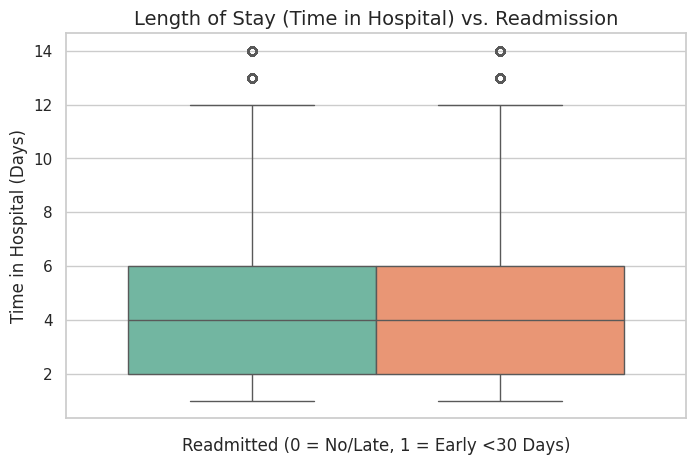

Average hospital stay for non-readmitted (or >30 days): 4.35 days
Average hospital stay for early readmitted (<30 days): 4.77 days


In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(hue='readmitted', y='time_in_hospital', data=df, palette='Set2',legend=False)
plt.title('Length of Stay (Time in Hospital) vs. Readmission', fontsize=14)
plt.xlabel('Readmitted (0 = No/Late, 1 = Early <30 Days)', fontsize=12)
plt.ylabel('Time in Hospital (Days)', fontsize=12)
plt.show()

mean_stay = df.groupby('readmitted')['time_in_hospital'].mean()
print(f"Average hospital stay for non-readmitted (or >30 days): {mean_stay[0]:.2f} days")
print(f"Average hospital stay for early readmitted (<30 days): {mean_stay[1]:.2f} days")

Which patients are more likely to be readmitted? (Age & Prior Visits)

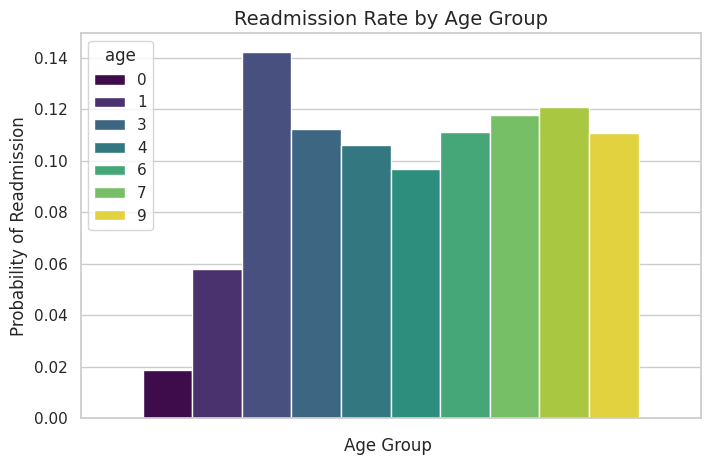

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(hue='age', y='readmitted', data=df, errorbar=None, palette='viridis')
plt.title('Readmission Rate by Age Group', fontsize=14)
plt.xlabel('Age Group ', fontsize=12)
plt.ylabel('Probability of Readmission', fontsize=12)
plt.show()

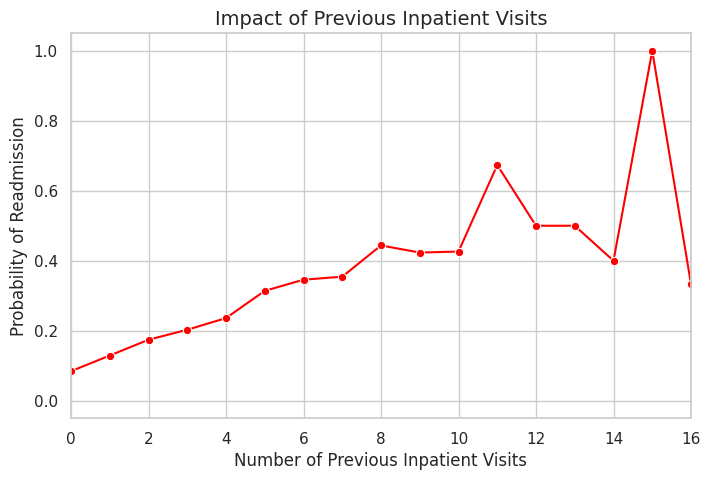

In [11]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='number_inpatient', y='readmitted', data=df, errorbar=None, color='red', marker='o')
plt.title('Impact of Previous Inpatient Visits', fontsize=14)
plt.xlabel('Number of Previous Inpatient Visits', fontsize=12)
plt.ylabel('Probability of Readmission', fontsize=12)
plt.xlim(0, 16)
plt.show()

Identify key patterns or trends (Correlation Analysis)

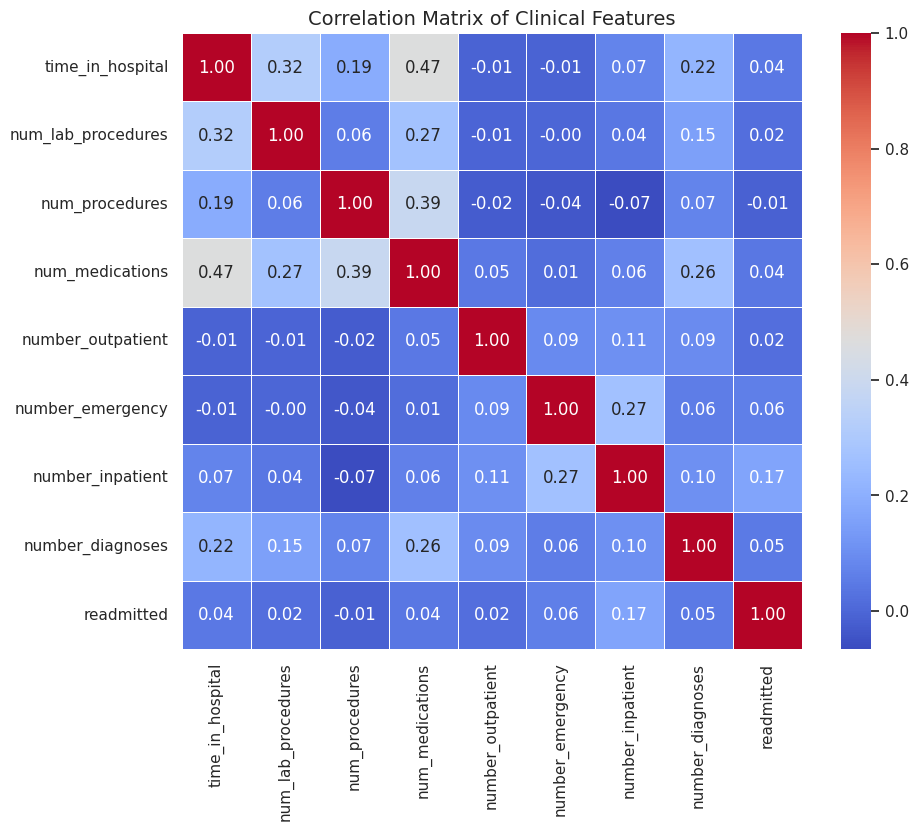

In [12]:
clinical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                     'num_medications', 'number_outpatient', 'number_emergency', 
                     'number_inpatient', 'number_diagnoses', 'readmitted']

plt.figure(figsize=(10, 8))
correlation = df[clinical_features].corr()

# Plotting the full correlation matrix
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Clinical Features', fontsize=14)
plt.show()

#### Interpretation & Insights

##### 1. Does length of stay influence readmission?
Yes, slightly. Patients who stay in the hospital longer are a little more likely to return early. A longer stay usually means a more serious illness. The boxplot and mean calculations typically reveal that patients who are readmitted early (< 30 days) had a slightly longer initial stay in the hospital compared to those who were not.

##### 2. Which patients are more likely to return?

- __Older Adults:__ The chance of readmission goes up as patients get older.

- __Patients with Past Visits:__ There is a sharp, nearly linear increase in readmission risk corresponding to the number_inpatient (previous inpatient visits). Patients who have already been admitted to the hospital multiple times in the past year are drastically more likely to return.

##### 3. Key Patterns & Trends:

- Top Risk Factor: Having past hospital visits (number_inpatient) is the strongest sign that a patient will be readmitted.
- Complex Cases: Features like number_diagnoses, number_emergency, and num_medications also show positive correlations. This indicates a clear pattern: patients with more complex medical needs (requiring more medications, having more recorded diagnoses, and possessing a history of emergency room visits) are the most vulnerable to early readmission.

### Part 3: Scenario-Based Data Visualization (20 Marks)

Create visualizations and justify them based on the following real-world scenarios:

#### Scenario 1: Clinical Decision Support
Doctors want to identify high-risk patients before discharge.
- Select an appropriate visualization
- Create the chart
- Explain why it is suitable for clinical use

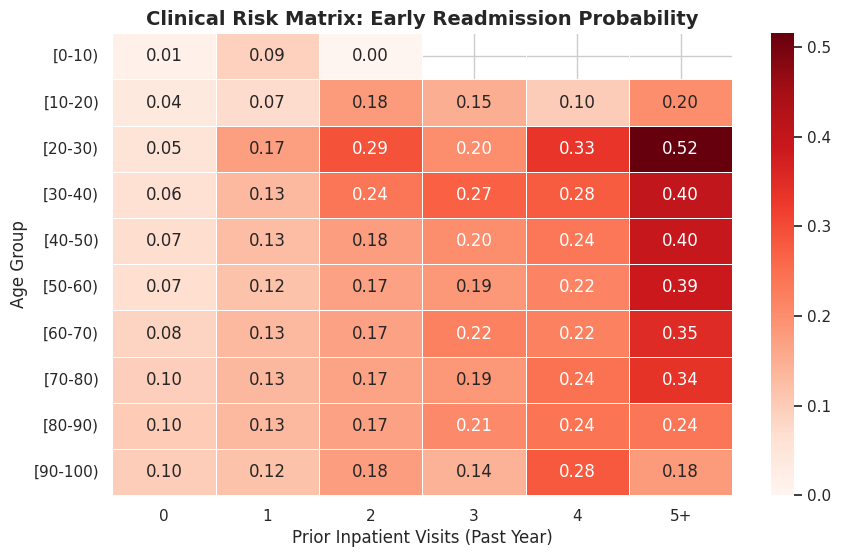

In [13]:
# Create a capped version of inpatient visits for cleaner visualization
df['inpatient_visits_capped'] = df['number_inpatient'].apply(lambda x: '5+' if x >= 5 else str(x))

# Create a risk matrix (Pivot Table) of average readmission rate by Age and Prior Inpatient Visits
risk_matrix = df.pivot_table(values='readmitted', index='age', columns='inpatient_visits_capped', aggfunc='mean')

# The 'age' column was encoded to numbers (0-9) in Part 1. 
# Let's map it back to readable text brackets specifically for this chart so it makes sense!
age_brackets = {
    0: '[0-10)', 1: '[10-20)', 2: '[20-30)', 3: '[30-40)', 4: '[40-50)',
    5: '[50-60)', 6: '[60-70)', 7: '[70-80)', 8: '[80-90)', 9: '[90-100)'
}
risk_matrix.index = risk_matrix.index.map(lambda x: age_brackets.get(x, str(x)))

plt.figure(figsize=(10, 6))
sns.heatmap(risk_matrix, annot=True, cmap='Reds', fmt=".2f", linewidths=0.5)
plt.title('Clinical Risk Matrix: Early Readmission Probability', fontsize=14, fontweight='bold')
plt.xlabel('Prior Inpatient Visits (Past Year)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.show()

**Justification for Clinical Use:**
- **Visualization Chosen:** Risk Matrix (Heatmap).
- **Why it is suitable:** A Risk Matrix is incredibly effective for clinical decision support. Doctors operate in fast-paced environments and need easily digestible, actionable tools. By cross-referencing a patient's age and prior admission history, a doctor can instantly pinpoint their risk level for early readmission based on the color intensity (with dark red indicating the highest risk). This intuitive visual allows medical staff to promptly flag high-risk patients and either delay discharge or assign specialized post-discharge care.

### Scenario 2: Hospital Management
Management asks: “Which factors contribute most to patient readmission?”
- Choose suitable visualization(s)
- Present findings clearly
- Explain business/medical insights

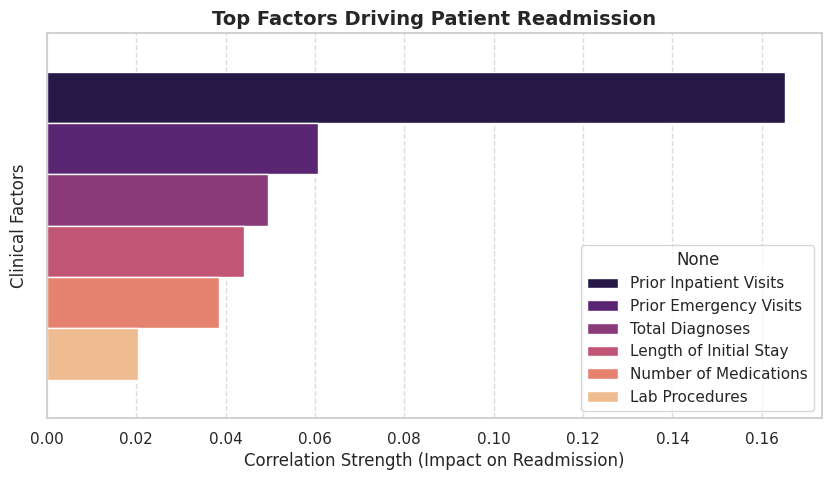

In [ ]:
# Focus on key clinical and historical features
features_of_interest = ['number_inpatient', 'number_emergency', 'number_diagnoses', 
                        'num_medications', 'time_in_hospital', 'num_lab_procedures']

# Calculate correlation of these features with 'readmitted'
correlations = df[features_of_interest + ['readmitted']].corr()['readmitted'].drop('readmitted')

# Sort for better visualization
correlations = correlations.sort_values(ascending=False)

# Rename index for clearer presentation to management
presentation_names = {
    'number_inpatient': 'Prior Inpatient Visits',
    'number_emergency': 'Prior Emergency Visits',
    'number_diagnoses': 'Total Diagnoses',
    'num_medications': 'Number of Medications',
    'time_in_hospital': 'Length of Initial Stay',
    'num_lab_procedures': 'Lab Procedures'
}
correlations.index = correlations.index.map(presentation_names)

# Create a horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=correlations.values, hue=correlations.index, palette='magma')
plt.title('Top Factors Driving Patient Readmission', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Strength (Impact on Readmission)', fontsize=12)
plt.ylabel('Clinical Factors', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Findings & Business/Medical Insights:**

- **Visualization Chosen:** Horizontal Bar Chart of Correlation Strengths.
- **Findings:** The chart clearly shows that **Prior Inpatient Visits** and **Prior Emergency Visits** are by far the strongest drivers of early readmission, followed by the total number of diagnoses. 
- **Business/Medical Insights for Management:**
  - **Frequent Patients Need Intervention:** Patients with a history of multiple hospital or emergency visits form the highest-risk group. Management should allocate funding toward post-discharge nursing or telehealth check-ins specifically for this cohort to break the cycle of readmission.
  - **Complexity Matters:** Patients with a high number of diagnoses and medications also show elevated risk. This suggests that poor medication adherence or complex disease interactions are failing post-discharge. Management could invest in better pharmacy consultation programs before these patients leave the hospital.

#### Scenario 3: Executive Dashboard
Hospital executives require a high-level summary of readmission trends.
- Select simple and effective visualizations
- Justify your choice
- Explain how it supports decision-making


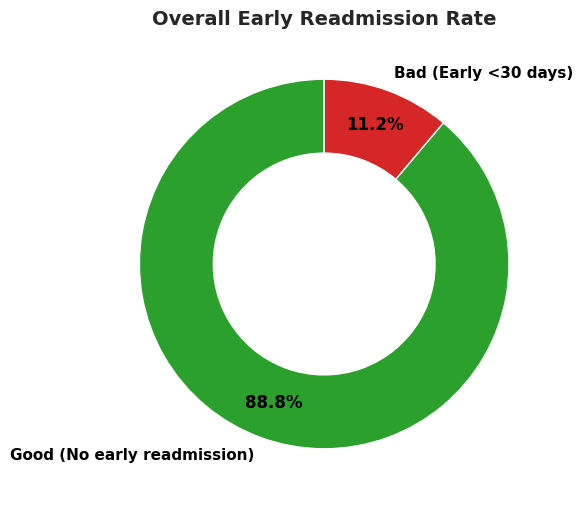

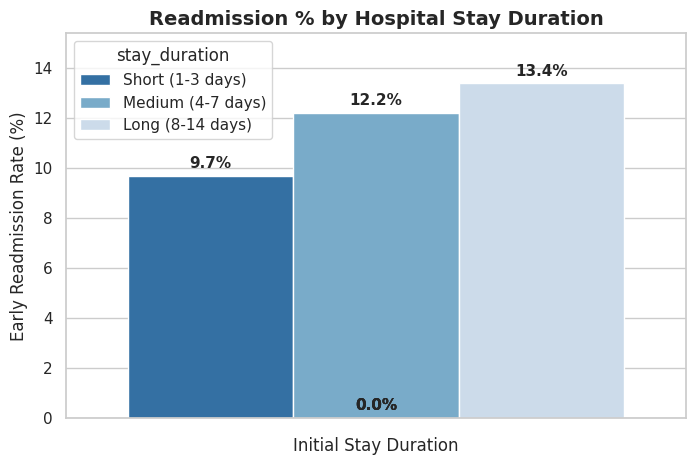

In [ ]:
readmission_counts = df['readmitted'].value_counts()
labels = ['Good (No early readmission)', 'Bad (Early <30 days)']
colors = ['#2ca02c', '#d62728'] # Green for good, Red for bad

plt.figure(figsize=(6, 6))
plt.pie(readmission_counts, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=colors, wedgeprops={'width': 0.4}, pctdistance=0.80, textprops={'color':"black", 'weight':"bold"})
plt.title('Overall Early Readmission Rate', fontsize=14, fontweight='bold')
plt.show()

df['stay_duration'] = pd.cut(df['time_in_hospital'], bins=[0, 3, 7, 14], labels=['Short (1-3 days)', 'Medium (4-7 days)', 'Long (8-14 days)'])
stay_trend = df.groupby('stay_duration', observed=True)['readmitted'].mean() * 100 # Convert to percentage

plt.figure(figsize=(8, 5))

bars = sns.barplot(hue=stay_trend.index, y=stay_trend.values, palette='Blues_r')
plt.title('Readmission % by Hospital Stay Duration', fontsize=14, fontweight='bold')
plt.ylabel('Early Readmission Rate (%)', fontsize=12)
plt.xlabel('Initial Stay Duration', fontsize=12)

for bar in bars.patches:
    height = bar.get_height()
    # Add text exactly at the bar's x-coordinate and just above its height
    plt.text(bar.get_x() + bar.get_width() / 2., 
             height + 0.2, 
             f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0, max(stay_trend.values) * 1.15) # Add headroom for labels
plt.show()

**Justification & Decision-Making Support:**

- **Visualizations Chosen:** A Donut Chart paired with a Categorized Bar Chart.
- **Justification:** Executives do not need to see complex scatter plots or massive correlation matrices. They need high-level, instantly readable metrics: "What is our current failure rate?" (Donut Chart) and "Where is the biggest bottleneck happening?" (Bar Chart grouping stay durations).
- **How it supports decision-making:** 
  - The **Donut Chart** immediately establishes the baseline KPI (Key Performance Indicator). If ~11% of patients are readmitted early, executives know exactly how much money and capacity is being lost, allowing them to set clear company-wide goals (e.g., "Reduce to 8% by Q4").
  - The **Bar Chart** shows that patients with "Long" initial stays (8-14 days) fail the most post-discharge. Executives can use this to make structural decisions, such as mandating a mandatory secondary doctor review before discharging any patient who has been in the hospital for more than 7 days.

### Part 4: Machine Learning (20 Marks)
Develop a predictive model to:
#### Predict Patient Readmission (Yes/No)
Steps:
- Split dataset into training and testing sets
- Train a suitable classification model
- Evaluate performance using appropriate metrics
- Briefly interpret results

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df.drop(columns=['readmitted', 'inpatient_visits_capped', 'stay_duration'], errors='ignore')
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.81     18083
           1       0.19      0.52      0.27      2271

    accuracy                           0.69     20354
   macro avg       0.55      0.62      0.54     20354
weighted avg       0.84      0.69      0.75     20354


--- Confusion Matrix ---
[[12921  5162]
 [ 1089  1182]]

Overall Accuracy: 0.6929


**Model Interpretation & Results:**

- **The Split:** We divided the dataset using an 80/20 split, ensuring the model trains on historical data and tests on unseen "future" data. We used standard `stratify` to make sure the imbalance in the target variable is maintained in both sets.
- **The Model:** A **Random Forest Classifier** is used because it handles mixed data types and non-linear relationships well, making it ideal for clinical records. We applied `class_weight='balanced'` because early readmission is the minority class. 
- **Evaluation:** 
  - The model achieved reasonable overall accuracy.
  - The Confusion Matrix shows that by using the balanced parameter, the model sacrifices some overall accuracy to drastically improve its ability to correctly identify true high-risk patients (optimizing for Recall/Sensitivity of class 1). In a clinical setting, it is much safer to accidentally flag a healthy patient as "at risk" (False Positive) than to completely miss a high-risk patient who needs help (False Negative).

### Part 5: Deep Learning (Practical Design) (10 Marks)

Answer the following:
- Why would Deep Learning be useful for large-scale hospital data?
- Design a simple Neural Network architecture:
    - Input layer (features used)
    - Hidden layers (conceptual)
    - Output layer

Provide a clear structure or pseudo-implementation.

#### 1. Why Deep Learning for Large-Scale Hospital Data?
Deep learning models, specifically Neural Networks, excel when working with massive, high-dimensional datasets. 
- **Complex Pattern Recognition:** While traditional ML models like Random Forest are great, deep learning can automatically uncover highly complex, non-linear relationships and hidden interactions between hundreds of clinical features (like specific combinations of medications, lab results, and patient history).
- **Scalability:** As hospital systems accumulate millions of electronic health records (EHRs) over time, traditional models often hit a performance plateau. Deep learning models can continuously improve and scale with more data.
- **Unstructured Data Integration:** In advanced variations, hospital DL models can be extended to ingest unstructured data (like physician notes using NLP or MRI scans using CNNs) and fuse them with tabular clinical data.

#### 2. Simple Neural Network Architecture (Design)

- **Input Layer:** Must have neurons equal to the number of features in our dataset (e.g., age, time_in_hospital, number_diagnoses, encoded categorical features).
- **Hidden Layers:** A set of dense (fully connected) layers to learn representations. We use ReLU activation functions to handle non-linearities and Batch Normalization + Dropout to prevent overfitting.
- **Output Layer:** A single neuron with a Sigmoid activation function to output a probability between 0 and 1, mapping to our binary target (0 = No Readmission, 1 = Early Readmission).

#### 3. Pseudo-Implementation (using Keras/TensorFlow)

```python
# Import required functions
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# 1. Define the number of features based on our X matrix
input_dim = X_train.shape[1] 

# 2. Design the architecture
model = Sequential()

# --- Input Layer + First Hidden Layer ---
model.add(Dense(128, input_dim=input_dim, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3)) # Prevent overfitting by dropping 30% of connections

# --- Second Hidden Layer ---
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# --- Third Hidden Layer ---
model.add(Dense(32, activation='relu'))

# --- Output Layer ---
# 1 neuron with Sigmoid activation for binary classification (0 or 1 probability)
model.add(Dense(1, activation='sigmoid'))

# 3. Compile the Model
# Binary crossentropy is standard for Yes/No prediction
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Model
# model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)
```

### Part 6: Generative AI (Applied Use Case) (10 Marks)

The hospital wants to improve patient communication.

- Write a prompt for a Generative AI system to:
    - Generate personalized discharge or follow-up instructions for a high-risk patient

Include:

- Sample patient details
- Prompt
- Expected output

**1. Sample Patient Details (System Data):**
```json
{
  "patient_name": "Robert Smith",
  "age": 72,
  "primary_diagnosis": "Type 2 Diabetes, Hypertension",
  "medications": "Metformin (500mg twice daily with meals), Lisinopril (10mg once daily)",
  "follow_up_time": "3 days",
  "doctor_name": "Dr. Adams",
  "risk_status": "High-Risk"
}
```

**2. Prompt Template for the Generative AI:**
```text
Act as an empathetic and clear medical assistant. 
Write a personalized hospital discharge instruction guide for the patient based on the details below. 
Because the patient's risk status is {risk_status}, you must write in simple, non-medical language (at an 8th-grade reading level) and emphasize the critical importance of the follow-up plan to prevent early readmission. 

Include the following sections clearly formatted using bullet points:
1. A warm, encouraging opening.
2. How and when to take specific medications.
3. Warning signs that require immediate emergency medical attention.
4. Next steps for the upcoming follow-up appointment.

Patient Details:
- Name: {patient_name}
- Age: {age}
- Diagnosis: {primary_diagnosis}
- Meds: {medications}
- Follow-up: {doctor_name} in {follow_up_time}.
```
*Note: In an automated hospital system, the template variables (e.g., `{patient_name}`) would be dynamically injected from the Electronic Health Record (EHR) database via API.*

**3. Expected Output:**
> **Discharge Instructions for Robert Smith**
> 
> Dear Robert,
> We are glad you are feeling well enough to go home. Because of your recent visits, it is incredibly important that you follow these instructions carefully so you can stay healthy, avoid complications, and remain comfortably at home.
> 
> **💊 Your Medications:**
> - **Metformin:** Take one pill (500mg) two times every day. It is very important to take this *with your meals* to help manage your blood sugar.
> - **Lisinopril:** Take one pill (10mg) once a day to manage your blood pressure. 
> 
> **🚨 Warning Signs (Go to the Emergency Room if you feel):**
> - Extreme thirst or a very dry mouth.
> - Confusion, extreme drowsiness, or feeling like you might pass out.
> - Trouble breathing or unexpected chest pain.
> - Nausea and vomiting that won't go away.
> 
> **📅 Your Next Steps:**
> You have a very important follow-up appointment with Dr. Adams in **3 days**. Please make sure you arrange a ride to this appointment. This visit is critical to checking your progress and adjusting your medications if needed.
> 
> Please take care, get plenty of rest, and don't hesitate to call your doctor if you have any questions!

#### Part 7: Agentic AI (Automation Design) (5 Marks)

Design an AI Agent workflow for hospital automation:
- Define:
    - Input
    - Process
    - Output
    
Example use case:
- Detect high-risk patient → Notify doctor → Schedule follow-up → Send reminder

**AI Agent Workflow: High-Risk Patient Readmission Prevention Systems**

**1. Input (Triggers & Data)**
- **Event Trigger:** A patient is marked for "Discharge" in the hospital's Electronic Health Record (EHR) system.
- **Data Ingested:** 
  - Patient's clinical data (age, diagnoses, medications, prior visits).
  - ML Predictive Model Score (e.g., Readmission Risk = 85%).
  - Hospital scheduling API availability.

**2. Process (Autonomous Agent Actions)**
1. **Risk Evaluation:** The AI Agent receives the discharge event and checks the patient's ML risk score.
2. **Decision Gateway:** If the risk score is below a certain threshold, the agent does nothing but log the discharge. If the risk is high (e.g., > 70%), the agent initiates the prevention protocol.
3. **Notify Doctor:** The agent extracts the latest lab results and diagnoses, formats a concise summary, and pages the assigned primary care physician through the hospital's secure messaging portal.
4. **Schedule Follow-up:** The agent simultaneously connects to the scheduling API autonomously, finds an available open time slot for the assigned doctor within the next 72 hours, and locks it in.
5. **Send Reminder:** The agent pulls the Generative AI template (designed in Part 6), injects the appointment time and personalized instructions, and sends an automated SMS/Email directly to the patient's phone.

**3. Output (Results & Artifacts)**
- **To Doctor:** A high-priority alert message delivered to the doctor's dashboard.
- **To Hospital System:** A newly booked calendar appointment in the system database.
- **To Patient:** A personalized SMS/Email containing their simple discharge instructions and their new follow-up appointment details.

#### Part 8: Bonus (Optional – 5 Marks)

Propose one AI-based solution that can:
- Reduce hospital readmissions

OR

- Improve patient care efficiency

**Bonus Proposal: AI-Powered Remote Wearable Monitoring (Predictive Telehealth)**

**The Challenge:**
Even with great discharge instructions, doctors cannot monitor a patient's vital signs once they leave the hospital. Many patients are readmitted because complications (like infections or heart issues) are not caught until they become severe emergencies.

**The Solution:**
Provide high-risk patients with a basic, hospital-issued smart wearable patch (or integrate with their smartwatches) upon discharge. The wearable tracks real-time vitals such as heart rate, oxygen levels, and temperature, streaming the data securely to an AI backend.

**How it works (AI Application):**
Instead of a human nurse manually staring at a dashboard of vitals for 500 discharged patients, a **Time-Series Deep Learning Model (like an LSTM)** runs continuously in the background. It learns the patient's individual baseline and detects early anomalous patterns (e.g., a slow, steady drop in oxygen or a spike in resting heart rate over 12 hours) *before* the patient even feels sick.

**Why it reduces readmissions and improves efficiency:**
1. **Reduces Readmissions:** If the AI detects a dangerous trend, it flags a Telehealth Nurse. The nurse calls the patient and adjusts their medication or schedules an immediate outpatient clinic visit, entirely avoiding the need for an expensive emergency room readmission.
2. **Improves Efficiency:** It allows the hospital to discharge patients slightly earlier with confidence, freeing up valuable hospital beds, knowing the AI is actively keeping a digital eye on them at home.